Original Dataset:

   Route_ID  Distance_km  Fuel_Litres  Delivery_Time_min  Cost_per_trip
0         1         12.0          3.2                 25            120
1         2         25.0          6.1                 50            250
2         3          NaN          4.5                 35            180
3         4         30.0          7.2                 60            300
4         5         22.0          5.3                 45            220
5         6         15.0          3.8                 30            150
6         7         28.0          6.8                 55            270
7         8         35.0          8.0                 70            320
8         9         20.0          4.9                 40            200
9        10         26.0          NaN                 52            260

Dataset After Handling Missing Values:

   Route_ID  Distance_km  Fuel_Litres  Delivery_Time_min  Cost_per_trip
0         1    12.000000     3.200000                 25            120
1   

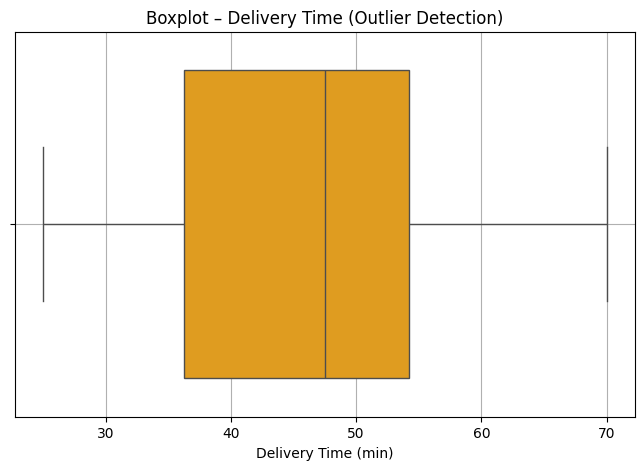

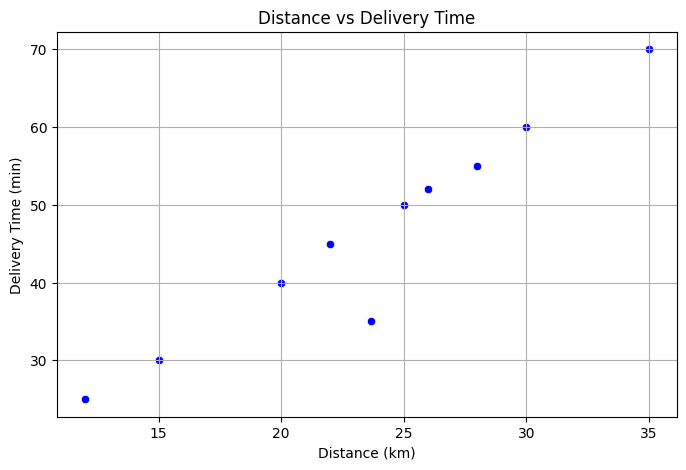

In [1]:
# Week 2 – Data Collection, Cleaning and Preprocessing for Logistics Analysis
# Author: Abinesh

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------
# 1. CREATE DUMMY LOGISTICS DATASET (DATA COLLECTION)
# ---------------------------------------------------------

data = {
    'Route_ID': [1,2,3,4,5,6,7,8,9,10],
    'Distance_km': [12,25,np.nan,30,22,15,28,35,20,26],
    'Fuel_Litres': [3.2,6.1,4.5,7.2,5.3,3.8,6.8,8.0,4.9,np.nan],
    'Delivery_Time_min': [25,50,35,60,45,30,55,70,40,52],
    'Cost_per_trip': [120,250,180,300,220,150,270,320,200,260]
}

df = pd.DataFrame(data)
print("Original Dataset:\n")
print(df)

# ---------------------------------------------------------
# 2. HANDLE MISSING VALUES (DATA CLEANING)
# ---------------------------------------------------------

df.fillna(df.mean(), inplace=True)
print("\nDataset After Handling Missing Values:\n")
print(df)

# ---------------------------------------------------------
# 3. OUTLIER DETECTION USING IQR METHOD
# ---------------------------------------------------------

Q1 = df['Delivery_Time_min'].quantile(0.25)
Q3 = df['Delivery_Time_min'].quantile(0.75)
IQR = Q3 - Q1

filtered_df = df[(df['Delivery_Time_min'] >= Q1 - 1.5*IQR) &
                 (df['Delivery_Time_min'] <= Q3 + 1.5*IQR)]

print("\nDataset After Removing Outliers:\n")
print(filtered_df)

# ---------------------------------------------------------
# 4. NORMALIZATION (PREPROCESSING)
# ---------------------------------------------------------

normalized_df = (filtered_df - filtered_df.min()) / (filtered_df.max() - filtered_df.min())
print("\nNormalized Dataset:\n")
print(normalized_df)

# ---------------------------------------------------------
# 5. VISUALIZATION (EVALUATION CRITERIA REQUIREMENT)
# ---------------------------------------------------------

# Boxplot for outlier detection
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Delivery_Time_min'], color='orange')
plt.title("Boxplot – Delivery Time (Outlier Detection)")
plt.xlabel("Delivery Time (min)")
plt.grid(True)
plt.show()

# Scatter plot for Distance vs Delivery Time
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['Distance_km'], y=df['Delivery_Time_min'], color='blue')
plt.title("Distance vs Delivery Time")
plt.xlabel("Distance (km)")
plt.ylabel("Delivery Time (min)")
plt.grid(True)
plt.show()
